# Modeling

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

In [ ]:
#for ROC AUC plots
from sklearn.metrics import auc, roc_curve 
import matplotlib as mpl 
import matplotlib.pyplot as plt

In [23]:
#for confusion matrix 
import seaborn as sns


In [2]:
#import modeling table 
os.chdir("/Users/annacarolinafagundes/ibd-myeloid-scoring/")
feature_matrix=pd.read_csv("data/processed/bulk/feature_matrix.csv")


In [3]:
#store label and data separately
data=feature_matrix.drop(columns=["Unnamed: 0","label"])
label=feature_matrix["label"]

In [4]:
#split train and test. training set 0.8 and test set 0.2 (this is standard practice)
#the first argument (data) gets split into X_train and X_test. 
#the second argument (label) gets split into y_train and y_test. 
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.2, random_state=42, stratify=label)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))

(1294, 12)
(324, 12)
label
CD         0.714838
Control    0.285162
Name: proportion, dtype: float64


## Scale data

### Some models require scaling (Logistic Regression, SVM and KNN). Based on sample size and the need for feature importance calculation, I will compare logistic regression and random forest- the latter does not require scaling, but scaling won't hurt it.

In [5]:
#create scaler and scale 
import sklearn.preprocessing
scaler=sklearn.preprocessing.StandardScaler()
x_train_scaled=scaler.fit_transform(X_train) #fit_transform always used on training set
x_test_scaled=scaler.transform(X_test) #transform only so it uses the same mean and sd learned from the training set


## Logistic regression

In [6]:
from sklearn.linear_model import LogisticRegression

#structure always the same for all models
#1. create model. 
model=LogisticRegression(max_iter=1000)
#2. fit model (1st arg scaled training data, 2nd arg training labels)
model.fit(x_train_scaled,y_train)
#3. test on test set
y_pred=model.predict(x_test_scaled)
y_pred

array(['CD', 'CD', 'CD', 'CD', 'CD', 'Control', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'Control', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'Control', 'CD',
       'CD', 'CD', 'Control', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'Control', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'CD', 'Control', 'CD', 'CD', 'Control', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'Control', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'Control', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD',
       'Control', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 'CD', 

### Compute metrics.
### Selection of metrics depends on the type of problem. Here we have binary classification (which excludes RMSE - regression) and accuracy (the data is disbalanced, so the model would already be 71% accurate if predicting CD bc of probability)

In [7]:
#Calculate F1 - precision and recall (ranges from 0-1, higher is better)
#Precision:of all the samples the model predicted as CD, how many actually were CD?
#Recall:of all the samples that truly are CD, how many did the model correctly identify?

from sklearn.metrics import classification_report
F1=classification_report(y_test, y_pred)
F1

#F1=0.84 CD strong performance - bc of imbalance
#F1=0.31 HC poor performance. needs to be trained so does not miss so many HCs

'              precision    recall  f1-score   support\n\n          CD       0.74      0.95      0.84       232\n     Control       0.59      0.17      0.27        92\n\n    accuracy                           0.73       324\n   macro avg       0.67      0.56      0.55       324\nweighted avg       0.70      0.73      0.67       324\n'

In [8]:
#Confusion matrix
#table showing true positives, false positives, true negatives, false negatives.
from sklearn.metrics import confusion_matrix
conf_matrix=confusion_matrix(y_test, y_pred)
conf_matrix

#still misses a lot of HC samples bc of data imbalance again

array([[221,  11],
       [ 76,  16]])

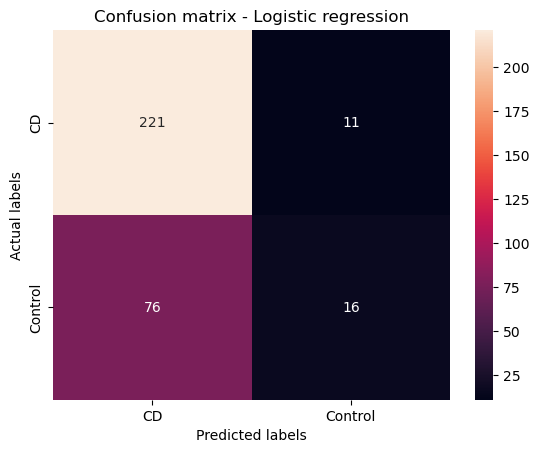

In [35]:
#plot Confusion matrix
sns.heatmap(conf_matrix,annot=True,fmt='d',xticklabels=['CD', 'Control'], yticklabels=['CD', 'Control'])
plt.xlabel("Predicted labels")
plt.ylabel("Actual labels")
plt.title("Confusion matrix - Logistic regression")
plt.savefig("figures/confusion_logistic.png")


In [10]:
#ROC-AUC
#measures how well the model separates the two classes. needs probabilities, not just class predictions. 
#more forgiving of imbalanced datasets than other methods
from sklearn.metrics import roc_auc_score
y_pred_prob=model.predict_proba(x_test_scaled) #similar to predict but returns prob
roc_auc=roc_auc_score(y_test,y_pred_prob[:,1]) #prob of predicting CD -positive class (column_2)
roc_auc


0.8112818590704647

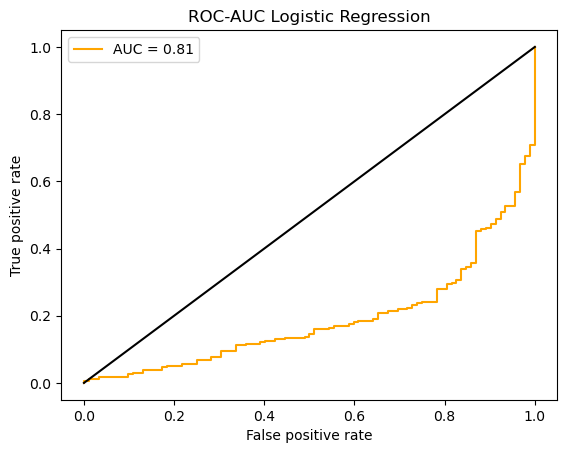

In [34]:
#calculate false (fpr) and true positive rate (tpr) and thresholds
fpr, tpr, thresholds=roc_curve(y_test,y_pred_prob[:,1], pos_label='CD')
#plot
plt.plot(fpr, tpr,label=f"AUC = {roc_auc:.2f}",color="orange") #rounds AUC to 2 decimal places
plt.plot([0, 1], [0, 1],color="black")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC-AUC Logistic Regression")
plt.legend() #to display AUC
plt.savefig("figures/roc_auc_logistic.png")


## Random forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

#structure always the same for all models
#1. create model. 100 is standard default of tree number. 42 is similar to set.seed
model_forest=RandomForestClassifier(n_estimators=100,random_state=42)
#2. fit model (1st arg scaled training data, 2nd arg training labels)
model_forest.fit(x_train_scaled,y_train)
#3. test on test set
y_pred_forest=model_forest.predict(x_test_scaled)
y_pred_proba_forest=model_forest.predict_proba(x_test_scaled)
y_pred_forest
y_pred_proba_forest

array([[0.69, 0.31],
       [0.62, 0.38],
       [0.55, 0.45],
       [0.84, 0.16],
       [0.35, 0.65],
       [0.59, 0.41],
       [0.6 , 0.4 ],
       [0.69, 0.31],
       [0.83, 0.17],
       [0.69, 0.31],
       [0.92, 0.08],
       [0.68, 0.32],
       [0.74, 0.26],
       [0.51, 0.49],
       [0.74, 0.26],
       [0.8 , 0.2 ],
       [0.89, 0.11],
       [0.75, 0.25],
       [0.64, 0.36],
       [0.96, 0.04],
       [0.72, 0.28],
       [0.9 , 0.1 ],
       [0.61, 0.39],
       [0.5 , 0.5 ],
       [0.9 , 0.1 ],
       [0.84, 0.16],
       [0.66, 0.34],
       [0.65, 0.35],
       [0.41, 0.59],
       [0.69, 0.31],
       [0.39, 0.61],
       [0.96, 0.04],
       [0.46, 0.54],
       [0.93, 0.07],
       [0.85, 0.15],
       [0.93, 0.07],
       [0.94, 0.06],
       [0.72, 0.28],
       [0.68, 0.32],
       [0.97, 0.03],
       [0.57, 0.43],
       [0.78, 0.22],
       [0.84, 0.16],
       [0.75, 0.25],
       [0.53, 0.47],
       [0.39, 0.61],
       [0.81, 0.19],
       [0.59,

### Compute metrics.

In [13]:
#Calculate F1 - precision and recall (ranges from 0-1, higher is better)
#Precision:of all the samples the model predicted as CD, how many actually were CD?
#Recall:of all the samples that truly are CD, how many did the model correctly identify?

from sklearn.metrics import classification_report
F1_forest=classification_report(y_test, y_pred_forest)
F1_forest

#F1=0.83 CD strong performance - bc of imbalance
#F1=0.37 HC still low but better than logistic

'              precision    recall  f1-score   support\n\n          CD       0.76      0.94      0.84       232\n     Control       0.61      0.25      0.35        92\n\n    accuracy                           0.74       324\n   macro avg       0.68      0.59      0.60       324\nweighted avg       0.72      0.74      0.70       324\n'

In [14]:
#Confusion matrix
#table showing true positives, false positives, true negatives, false negatives.
conf_matrix_forest=confusion_matrix(y_test, y_pred_forest)
conf_matrix_forest

#still misses more HC samples bc than logistic

array([[217,  15],
       [ 69,  23]])

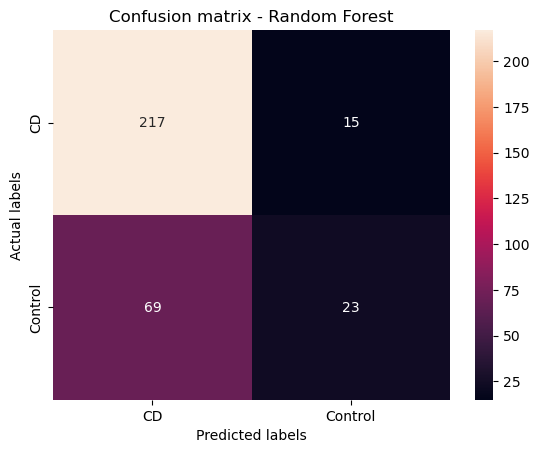

In [32]:
#plot Confusion matrix
sns.heatmap(conf_matrix_forest,annot=True,fmt='d',xticklabels=['CD', 'Control'], yticklabels=['CD', 'Control'])
plt.xlabel("Predicted labels")
plt.ylabel("Actual labels")
plt.title("Confusion matrix - Random Forest")
plt.savefig("figures/confusion_matrix_rf.png")

In [15]:
#ROC-AUC
#measures how well the model separates the two classes. needs probabilities, not just class predictions. 
#more forgiving of imbalanced datasets than other methods
from sklearn.metrics import roc_auc_score
roc_auc_forest=roc_auc_score(y_test,y_pred_proba_forest[:,1]) #prob of predicting CD -positive class (column_2)
roc_auc_forest

0.7206474887556221

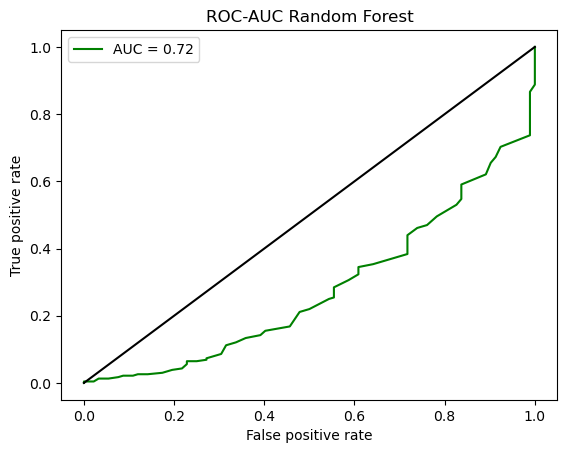

In [33]:
#calculate false (fpr) and true positive rate (tpr) and thresholds
fpr, tpr, thresholds=roc_curve(y_test,y_pred_proba_forest[:,1], pos_label='CD')
#plot
plt.plot(fpr, tpr,label=f"AUC = {roc_auc_forest:.2f}",color="green") #rounds AUC to 2 decimal places
plt.plot([0, 1], [0, 1],color="black")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC-AUC Random Forest")
plt.legend() #to display AUC
plt.savefig("figures/roc_auc_rf.png")


## Cross-validation
### train and evaluate multiple times to get a reliable estimate of performance. Model is thrown away after each evaluation. The end result is just an average score of all the evaluation chunks.

In [17]:
# Validate logistic regression model
from sklearn.model_selection import cross_val_score

#first scale ENTIRE dataset- not train and test separately
data_scaled=scaler.transform(data) #use same mean and std as before

#run cross validation
logistic_f1 = cross_val_score(model, data_scaled, label, cv=5, scoring="f1_weighted")
logistic_auc = cross_val_score(model, data_scaled, label, cv=5, scoring="roc_auc")

print(logistic_f1.mean(), logistic_f1.std())
print(logistic_auc.mean(), logistic_auc.std())

0.6916996344437855 0.03177921132516934
0.7568421355932842 0.012216715648369231


In [18]:
# Validate random forest model
from sklearn.model_selection import cross_val_score

#first scale ENTIRE dataset- not train and test separately
data_scaled=scaler.transform(data) #use same mean and std as before

#run cross validation
forest_f1 = cross_val_score(model_forest, data_scaled, label, cv=5, scoring="f1_weighted")
forest_auc = cross_val_score(model_forest, data_scaled, label, cv=5, scoring="roc_auc")

print(forest_f1.mean(), forest_f1.std())
print(forest_auc.mean(), forest_auc.std())

0.665288594961316 0.01851798938253818
0.6647937676270788 0.016681865127147474


### Logistic Regression is consistently better than Random Forest on this dataset (higher F1 and higher ROC-AUC). The std values are small for both models, meaning the scores are stable across folds. That's good. It means the result isn't a fluke of one particular split.

## Feature importance
### Which of the 12 myeloid cell type scores contributed most to the model's predictions

In [19]:
#logistic regression. returns 2d array and I want first row
importance_log=model.coef_[0]

#random forest. returns 1d array
importance_forest=model_forest.feature_importances_

In [20]:
#pair with features from dataframe
df_log=pd.DataFrame({
    "feature": data.columns,
    "importance": importance_log
}).sort_values("importance", ascending=False)

df_forest=pd.DataFrame({
    "feature": data.columns,
    "importance": importance_forest
}).sort_values("importance", ascending=False)

#feature importance in logistic regression: 
#Positive = pushes toward CD. Negative = pushes toward Control.
print(df_log) 

#feature importance in random forest: 
print(df_forest)


                   feature  importance
6                      DCs    1.610343
4        Mixed Macrophages    1.421475
9           M2 Macrophages    0.835844
3         M2.2 Macrophages    0.659976
10    M0_Ribhi Macrophages    0.570620
8          IDA Macrophages    0.022605
1             Neutrophil 1   -0.114873
5             Neutrophil 3   -0.404158
2             Neutrophil 2   -0.732286
0           M0 Macrophages   -1.117750
7           M1 Macrophages   -1.459430
11  Inflammatory Monocytes   -1.714993
                   feature  importance
5             Neutrophil 3    0.100250
1             Neutrophil 1    0.094258
4        Mixed Macrophages    0.093147
6                      DCs    0.088094
2             Neutrophil 2    0.084350
7           M1 Macrophages    0.082994
9           M2 Macrophages    0.081494
8          IDA Macrophages    0.077716
11  Inflammatory Monocytes    0.075675
10    M0_Ribhi Macrophages    0.075205
0           M0 Macrophages    0.074074
3         M2.2 Macrophage